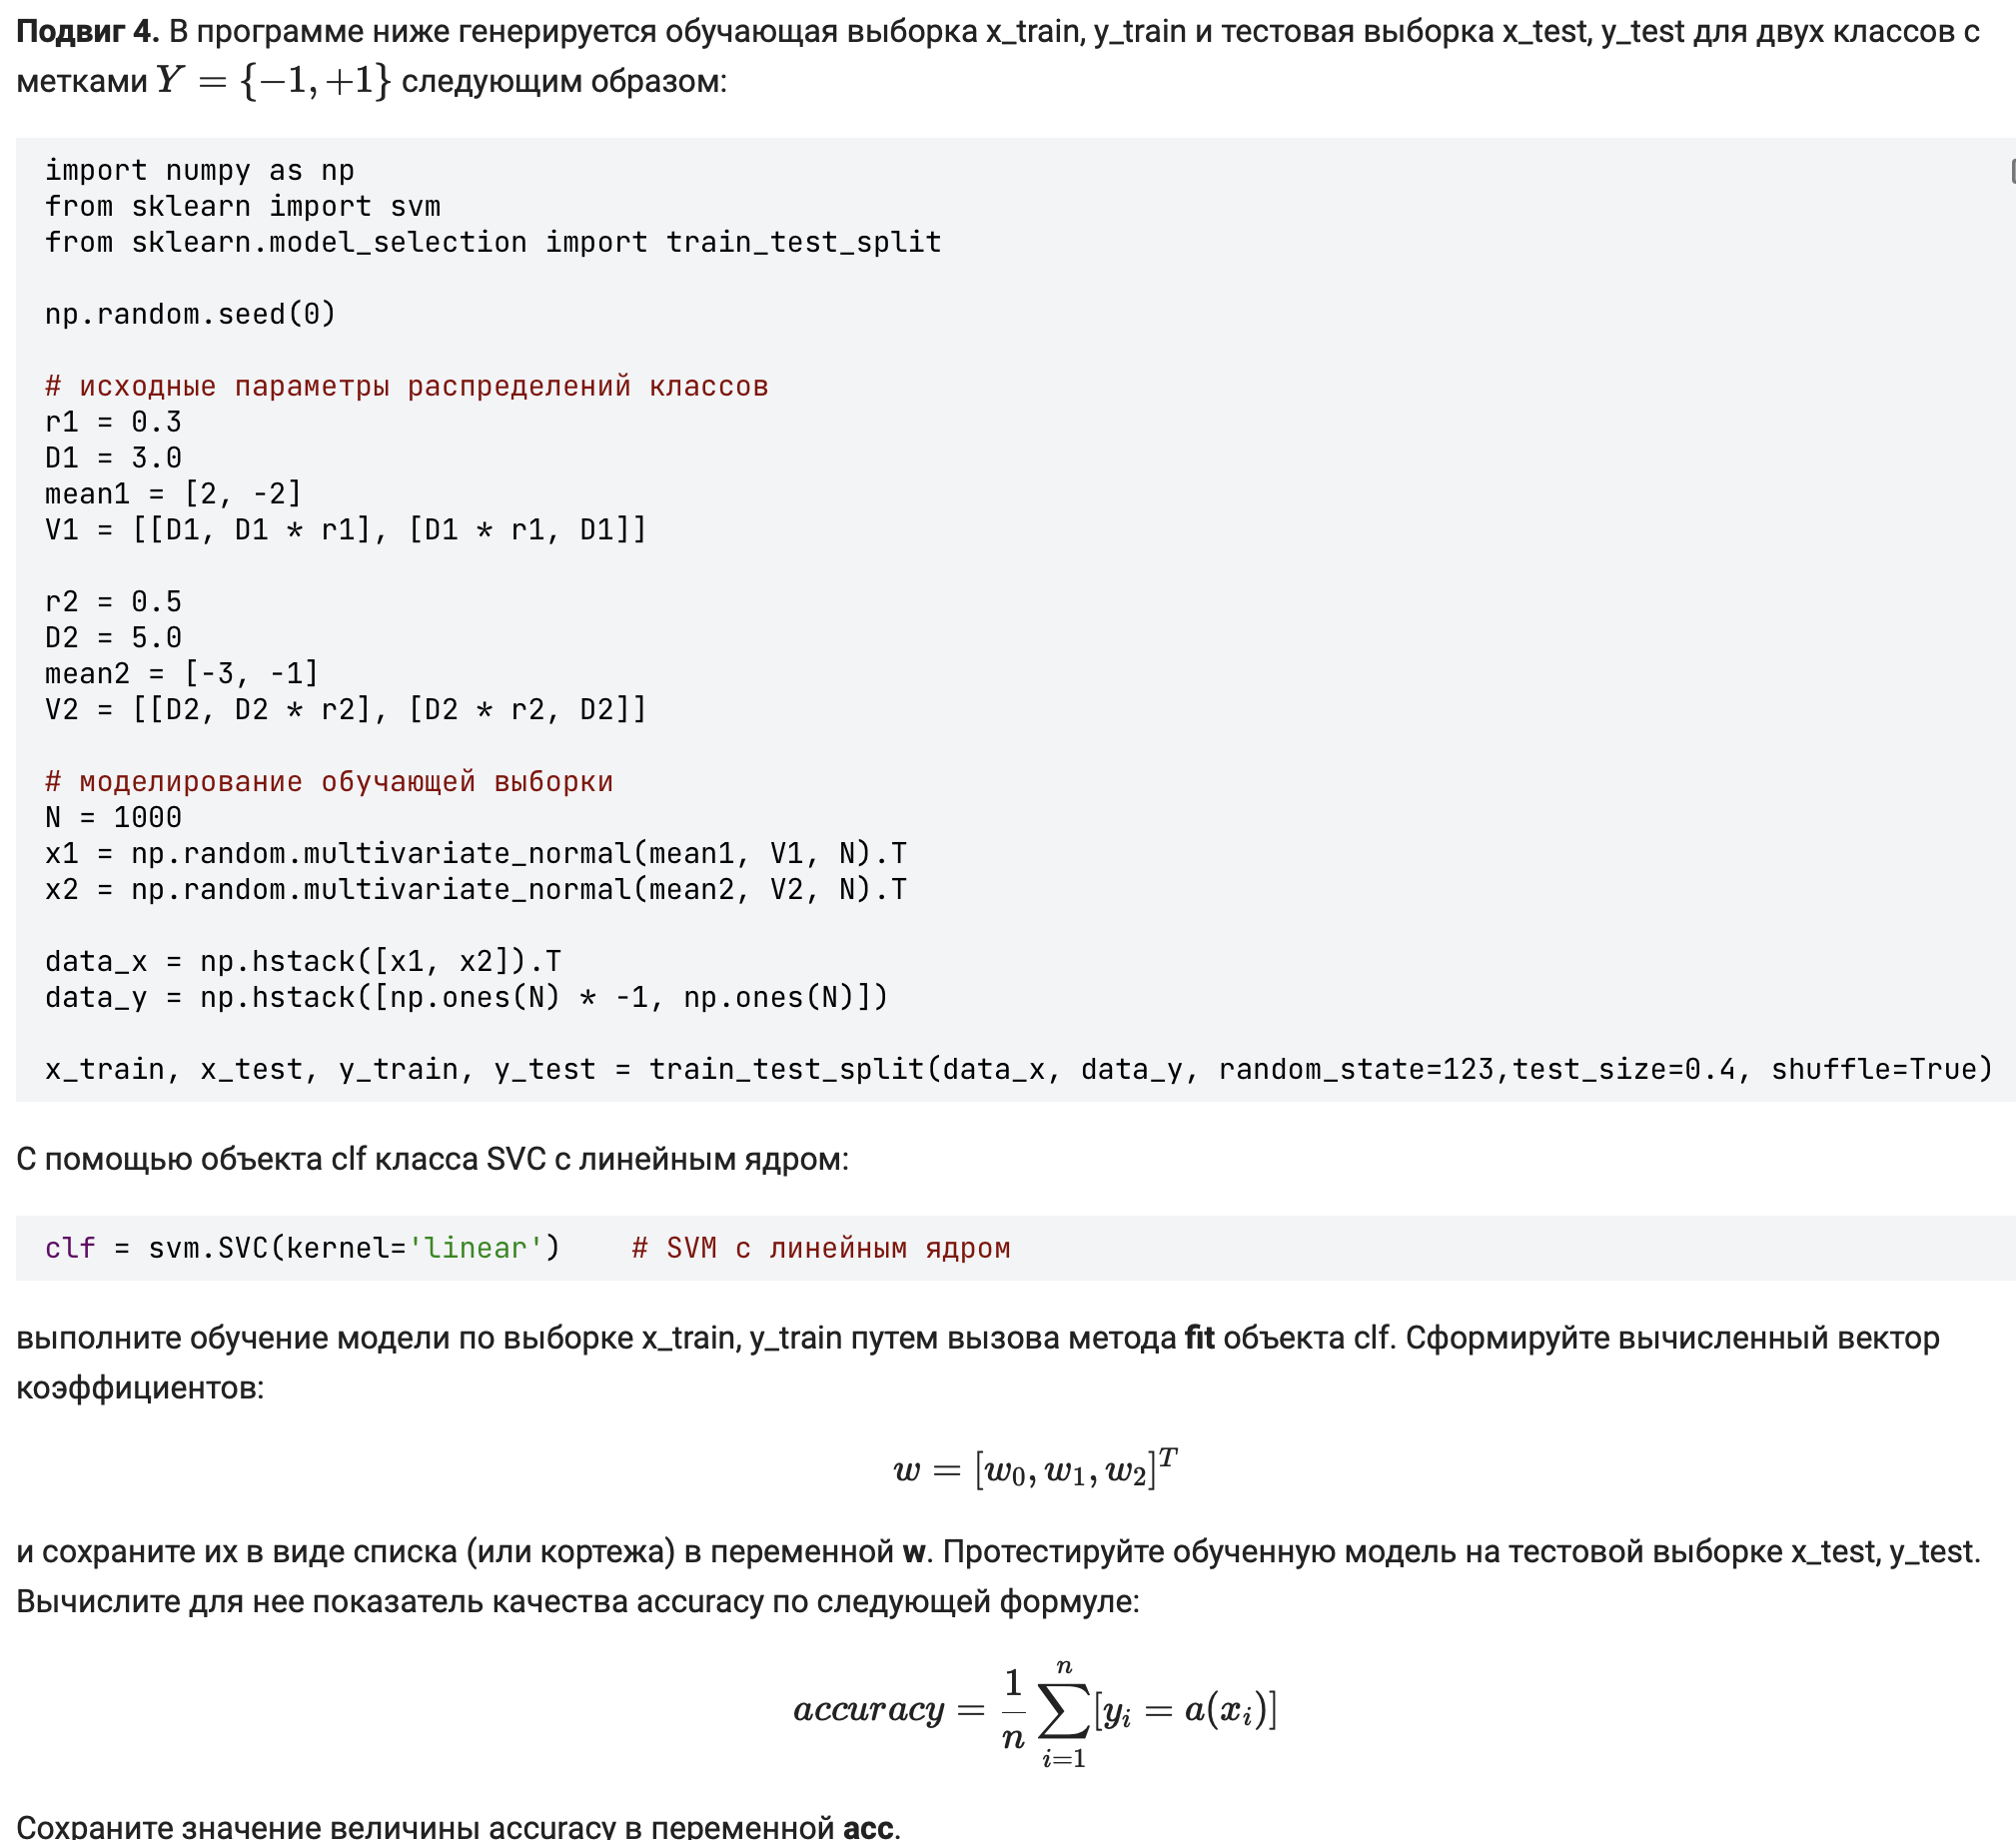

In [ ]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

np.random.seed(0)

# исходные параметры распределений классов
r1 = 0.3
D1 = 3.0
mean1 = [2, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 5.0
mean2 = [-3, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

data_x = np.hstack([x1, x2]).T
data_y = np.hstack([np.ones(N) * -1, np.ones(N)])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.4, shuffle=True)

# здесь продолжайте программу

clf = svm.SVC(kernel='linear')
clf.fit(x_train, y_train)
w12 = clf.coef_
w0 = clf.intercept_
w = np.hstack([w0.reshape(1, -1), w12]).T
acc = np.mean(y_test == clf.predict(x_test))

(1, 2) (1,)


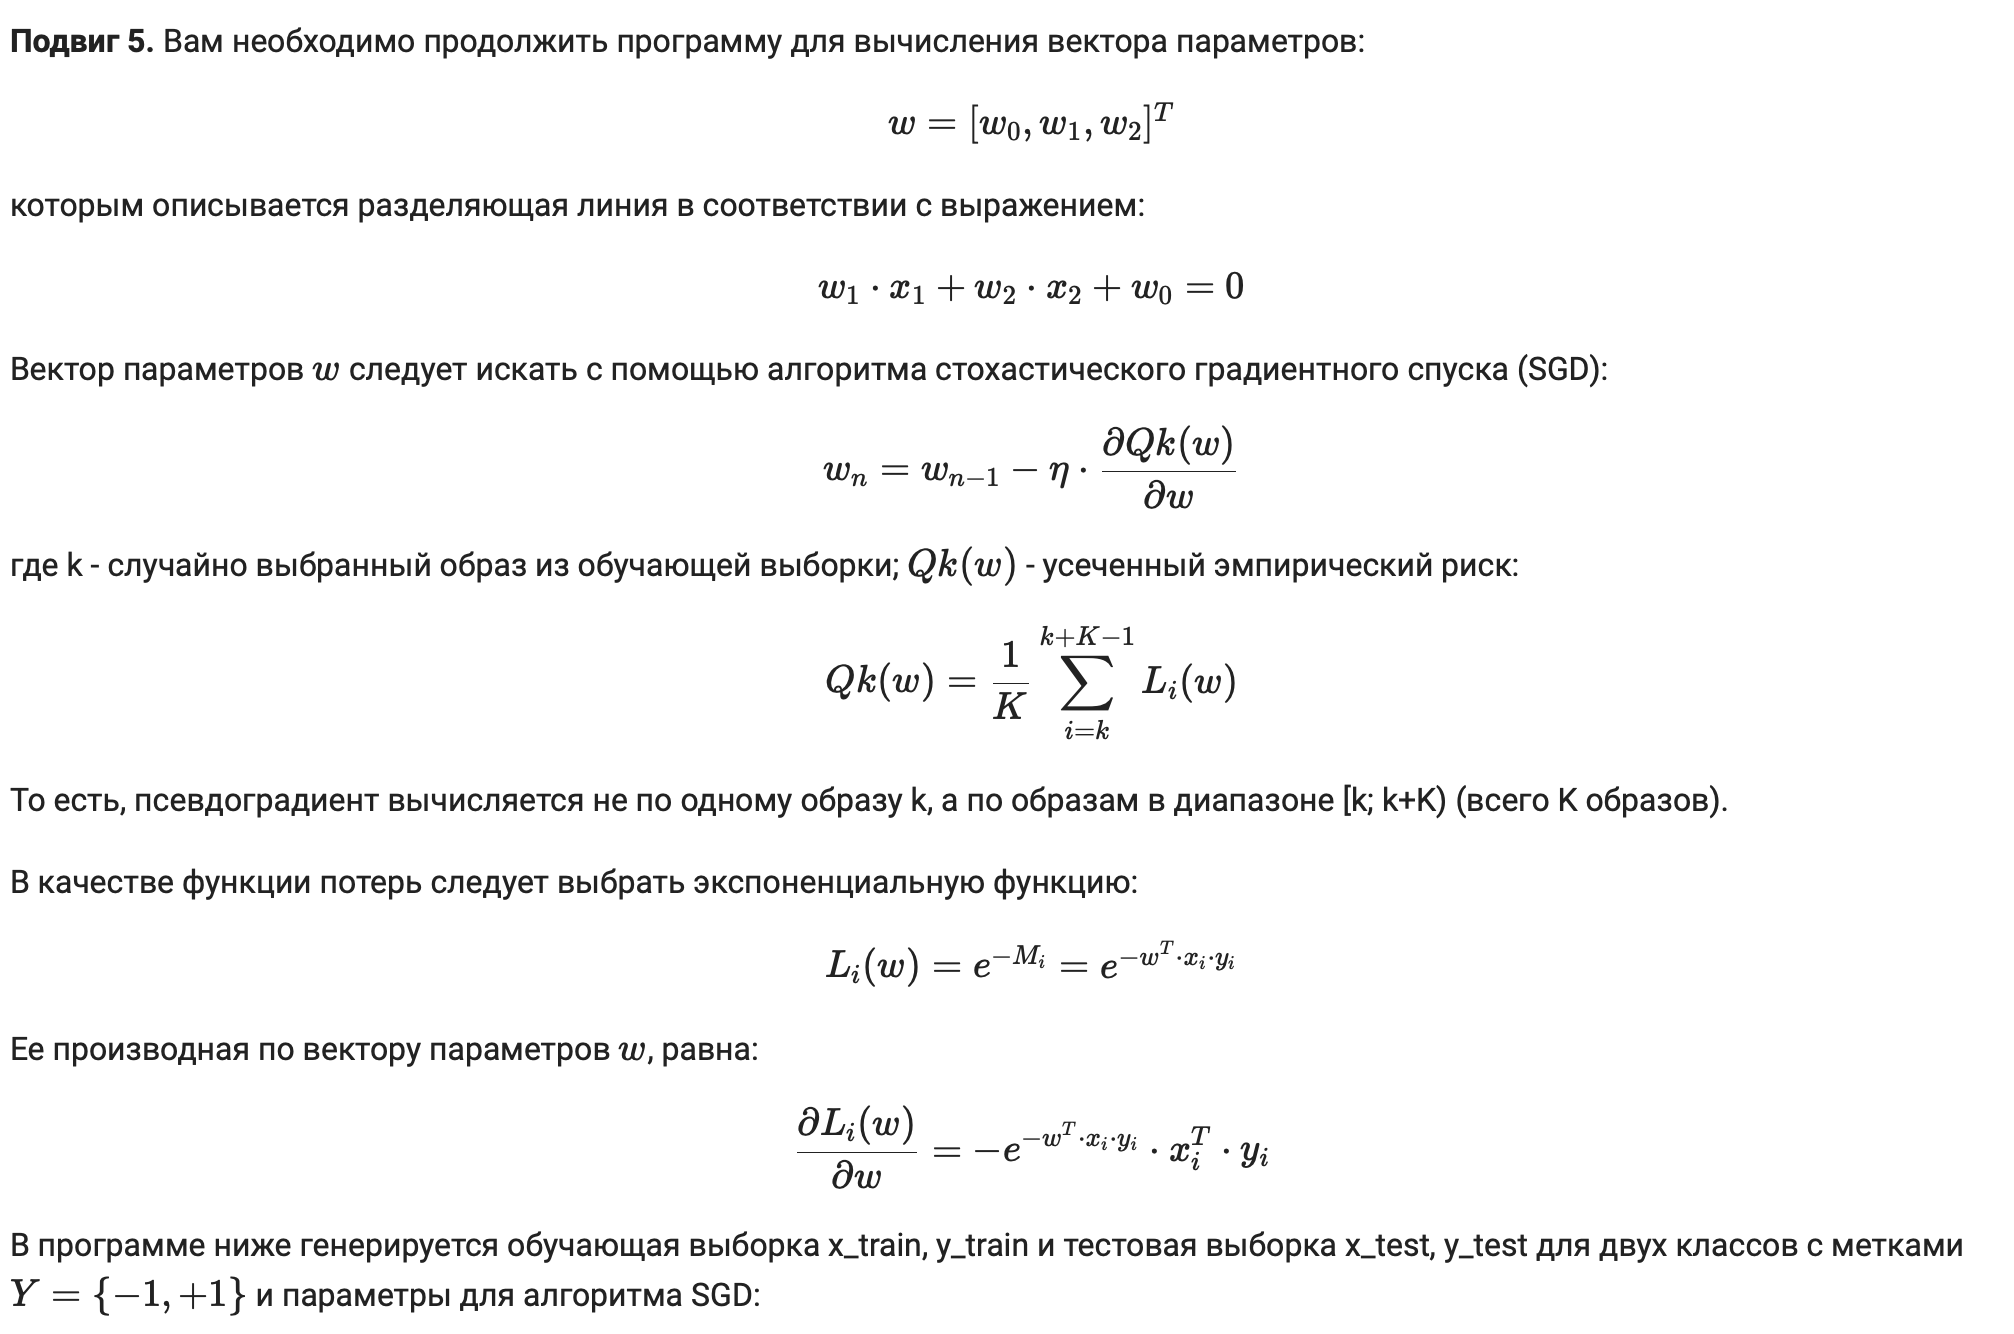
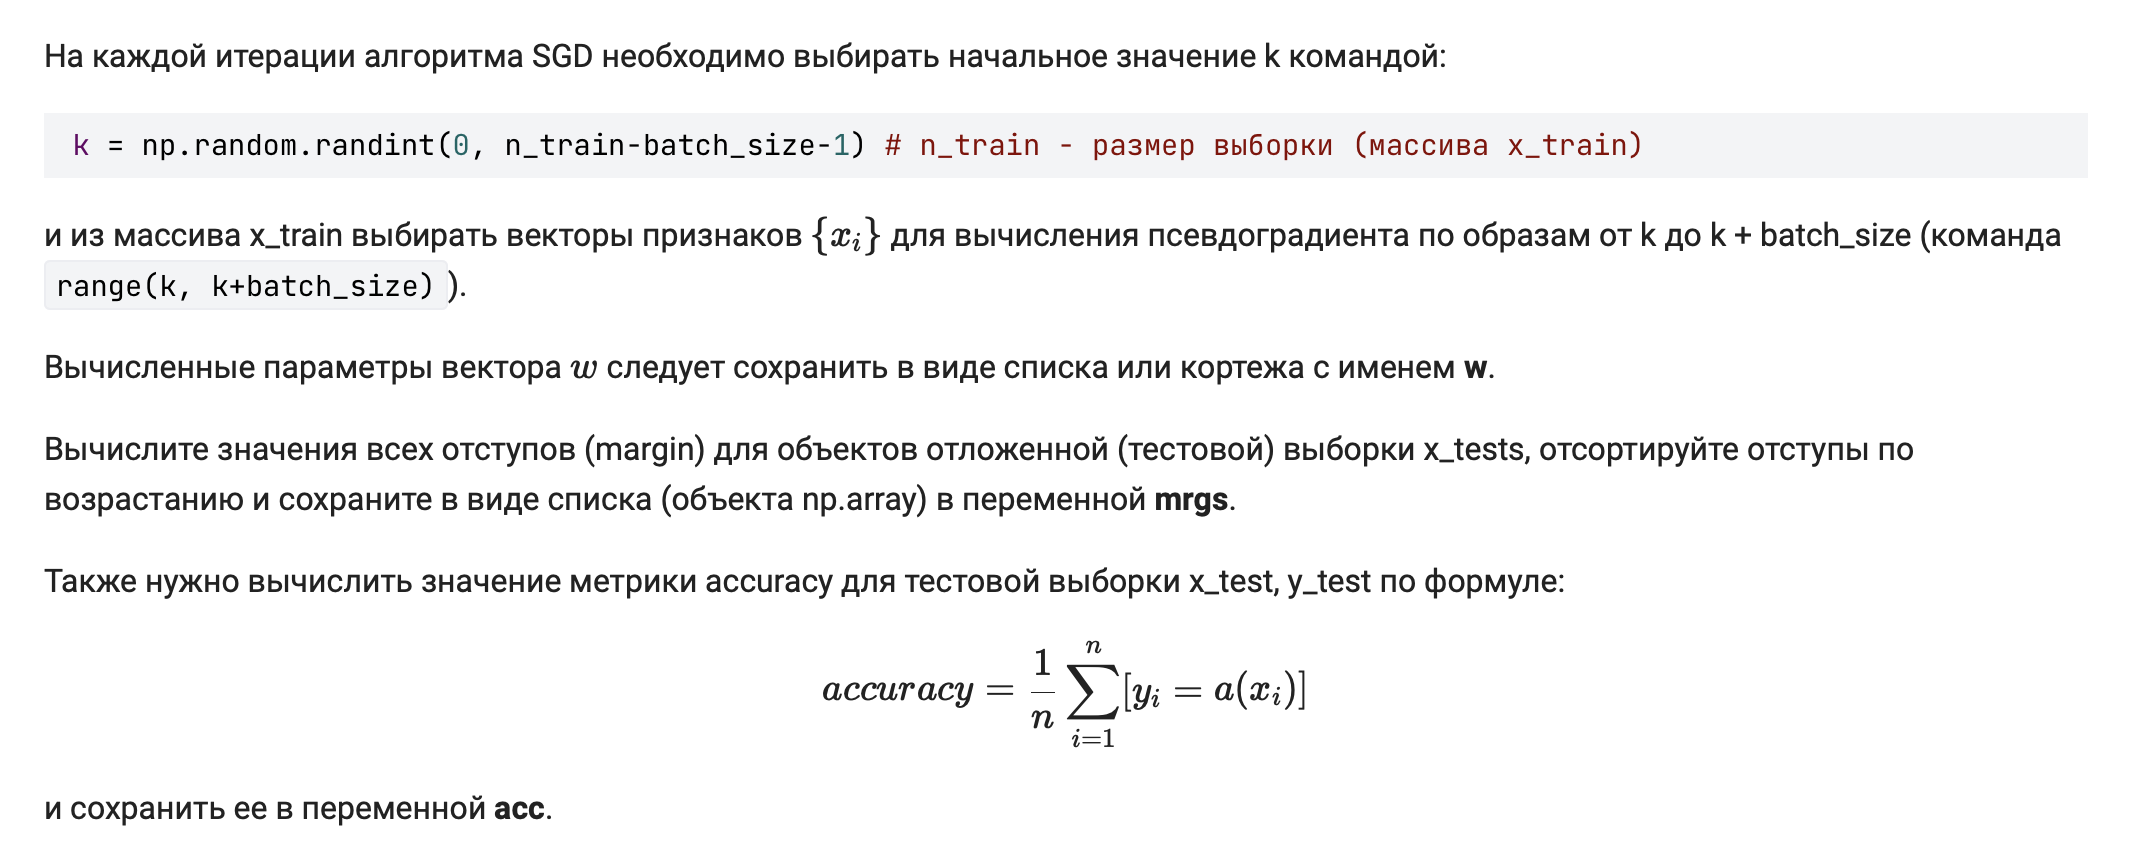

In [120]:
import numpy as np
from sklearn.model_selection import train_test_split

def loss(w, x, y):
    # здесь реализация экспоненциальной функции потерь
    return np.exp(-1 * x @ w * y)


# def df(w, x, y):
#     # здесь реализация производной функции потерь по вектору w
#     return -1 * loss(w, x, y) * y @ x

def df(w, x, y):
    # здесь реализация производной функции потерь по вектору w
    # Возвращает градиент как СУММУ по образцам (не среднее!)
    loss_values = loss(w, x, y)  # (n_samples,)
    # loss_values[:, np.newaxis] -> (n_samples, 1)
    # y[:, np.newaxis] -> (n_samples, 1)
    # x -> (n_samples, 3)
    return -np.sum(loss_values[:, np.newaxis] * (y[:, np.newaxis] * x), axis=0)


np.random.seed(0)

# исходные параметры распределений двух классов
r1 = 0.4
D1 = 2.0
mean1 = [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 3.0
mean2 = [2, 3]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 1000
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

data_x = np.array([[1, x[0], x[1]] for x in np.hstack([x1, x2]).T])
data_y = np.hstack([np.ones(N) * -1, np.ones(N)])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123, test_size=0.3, shuffle=True)

n_train = len(x_train)  # размер обучающей выборки
w = np.array([0.0, 0.0, 0.0])  # начальные весовые коэффициенты
nt = np.array([0.5, 0.01, 0.01])  # шаг обучения для каждого параметра w0, w1, w2
N = 500  # число итераций алгоритма SGD
batch_size = 10 # размер мини-батча (величина K = 10)

# здесь продолжайте программу
for i in range(N):
    k = np.random.randint(0, n_train-batch_size-1)
    X = x_train[k:k+batch_size]
    Y = y_train[k:k+batch_size]

    w -= nt * df(w, X, Y) / batch_size

mrgs = np.sort(w @ x_test.T * y_test)
acc = np.mean(np.sign(w @ x_test.T) == y_test)

w, acc, mrgs.shape

(array([-0.29321218, -0.28605492,  1.14218196]), np.float64(0.955), (600,))